In [1]:
# Cell 1: Imports & config
import os, gc, math
import numpy as np
import pandas as pd
import joblib
from collections import Counter

# ML
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

import lightgbm as lgb
import xgboost as xgb

# DL
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Plotting & widgets
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

# Repro
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Columns (as you described)
NUMERIC_COLS = ["Age","ESR","CRP","RF","C3","C4"]
CATEGORICAL_COLS = ["Gender","Anti-CCP","HLA-B27","ANA","Anti-Ro","Anti-La","Anti-dsDNA","Anti-Sm"]
LABEL_COL = "Disease"

# Paths (change if needed)
DATA_PATH = "expanded_medical_dataset_balanced_for_user.xlsx"   # <-- your uploaded dataset
BALANCED_PATH = "expanded_medical_dataset_balanced_for_user_n.xlsx"
MODEL_DIR = "/mnt/data/model_dir_final"
os.makedirs(MODEL_DIR, exist_ok=True)

# Top-K and training settings
TOP_K = 10
AE_EPOCHS = 120
LGB_N_ESTIMATORS = 1000


In [2]:
# Cell 2: Load & quick EDA
df = pd.read_excel(DATA_PATH)
print("Rows:", len(df))
display(df.head())
print("\nClass counts:")
display(df[LABEL_COL].value_counts())
print("\nNumeric summary:")
display(df[NUMERIC_COLS].describe())
print("\nMissing values per column:")
display(df.isna().sum())


Rows: 36304


,Age,Gender,ESR,CRP,RF,Anti-CCP,HLA-B27,ANA,Anti-Ro,Anti-La,Anti-dsDNA,Anti-Sm,C3,C4,Disease
0,51.652797,Male,40.562266,21.236560,31.511896,29.878108,Negative,Positive,Negative,Positive,Positive,Negative,88.352771,62.636149,rheumatoid arthritis
1,58.000000,Male,8.994000,3.658000,1.323000,17.812540,Positive,Negative,Positive,Positive,Positive,Positive,94.964000,6.481000,healthy
2,52.251090,Female,44.623256,13.500217,39.784524,28.143917,Negative,Negative,Positive,Negative,Negative,Negative,132.675943,71.540451,healthy
3,64.000000,Female,7.855000,0.000000,13.397000,36.944001,Negative,Negative,Positive,Negative,Negative,Positive,60.296000,13.126000,healthy
4,44.466441,Male,10.273786,13.782419,6.260292,38.465517,Negative,Positive,Positive,Positive,Positive,Positive,97.412037,19.156349,systemic lupus erythematosus



Class counts:


Disease
rheumatoid arthritis            12848
healthy                         12101
systemic lupus erythematosus    11355
Name: count, dtype: int64


Numeric summary:


,Age,ESR,CRP,RF,C3,C4
count,36304.000000,36304.000000,36304.000000,36304.000000,36304.000000,36304.000000
mean,49.570549,23.248074,12.570157,25.791312,108.685686,25.554819
std,17.487078,14.048158,9.243456,9.727069,40.534529,19.676105
min,-16.231228,-23.905022,-19.211513,-21.324286,-4.823327,-24.062173
25%,37.111787,10.751313,4.447000,20.861182,75.712487,9.210077
50%,49.648606,26.511088,13.723844,27.578195,104.258194,21.057248
75%,61.899338,35.000000,19.877883,32.440981,140.121032,39.732950
max,120.253818,61.186000,37.953826,67.073315,255.092000,110.391143



Missing values per column:


Age           0
Gender        0
ESR           0
CRP           0
RF            0
Anti-CCP      0
HLA-B27       0
ANA           0
Anti-Ro       0
Anti-La       0
Anti-dsDNA    0
Anti-Sm       0
C3            0
C4            0
Disease       0
dtype: int64

In [3]:
# Cell 3: Upsample healthy with small medically-plausible perturbations
from sklearn.utils import resample

# detect exact healthy label token (case preserved)
healthy_mask = df[LABEL_COL].astype(str).str.lower() == 'healthy'
if healthy_mask.sum() == 0:
    # fallback: choose least frequent label as healthy candidate
    smallest_label = df[LABEL_COL].value_counts().idxmin()
    healthy_token = smallest_label
    print("No explicit 'healthy' token. Using least frequent label as healthy:", healthy_token)
else:
    healthy_token = df.loc[healthy_mask, LABEL_COL].iloc[0]

df_healthy = df[df[LABEL_COL] == healthy_token].copy()
df_other = df[df[LABEL_COL] != healthy_token].copy()

print("Original class counts:")
print(df[LABEL_COL].value_counts())

# Choose target: mean of other class counts (safe); change to max() for stronger balancing
other_counts = df_other[LABEL_COL].value_counts()
target_healthy = int(other_counts.mean()) if len(other_counts)>0 else len(df_healthy)
target_healthy = max(target_healthy, len(df_healthy))
n_needed = target_healthy - len(df_healthy)
print(f"\nHealthy token: '{healthy_token}' | healthy before: {len(df_healthy)} | target: {target_healthy} | to add: {n_needed}")

if n_needed <= 0:
    print("No upsampling needed. Copying original file.")
    df.to_excel(BALANCED_PATH, index=False)
else:
    rng = np.random.default_rng(RANDOM_SEED)
    sampled = resample(df_healthy, replace=True, n_samples=n_needed, random_state=RANDOM_SEED)
    synth = []
    for _,row in sampled.iterrows():
        new = row.copy()
        # Age +/- ~2yrs
        try:
            age = float(new['Age'])
            age += int(rng.normal(0,2))
            if age < 0: age = abs(age)
            new['Age'] = int(round(age))
        except: pass
        # ESR, CRP: ~7% relative noise
        for col in ['ESR','CRP']:
            try:
                v = float(new[col])
                if v <= 0: v = max(0.0, v + rng.normal(0,0.5))
                else: v = v*(1.0 + float(rng.normal(0,0.07)))
                new[col] = round(max(0.0,v),3)
            except: pass
        # RF numeric noise
        try:
            v = float(new['RF'])
            if v <= 0: v = max(0.0, v + rng.normal(0,0.5))
            else: v = v*(1.0 + float(rng.normal(0,0.05)))
            new['RF'] = round(max(0.0,v),3)
        except: pass
        # C3, C4 small noise ~5%
        for col in ['C3','C4']:
            try:
                v = float(new[col])
                v = v*(1.0 + float(rng.normal(0,0.05)))
                new[col] = round(max(0.0,v),3)
            except: pass
        new[LABEL_COL] = healthy_token
        synth.append(new)
    df_synth = pd.DataFrame(synth)
    df_balanced = pd.concat([df, df_synth], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    df_balanced.to_excel(BALANCED_PATH, index=False)
    print("Saved balanced dataset to:", BALANCED_PATH)
    print("New class counts:")
    display(df_balanced[LABEL_COL].value_counts())

# For convenience, set df_balanced variable
if os.path.exists(BALANCED_PATH):
    df_balanced = pd.read_excel(BALANCED_PATH)
else:
    df_balanced = df.copy()


Original class counts:
Disease
rheumatoid arthritis            12848
healthy                         12101
systemic lupus erythematosus    11355
Name: count, dtype: int64

Healthy token: 'healthy' | healthy before: 12101 | target: 12101 | to add: 0
No upsampling needed. Copying original file.


In [4]:
# Cell 4: Preprocessing on balanced dataset
df = df_balanced.copy()  # use balanced
# numeric -> float, fill medians
df[NUMERIC_COLS] = df[NUMERIC_COLS].apply(pd.to_numeric, errors='coerce')
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())

# categorical fill
df[CATEGORICAL_COLS] = df[CATEGORICAL_COLS].fillna('NA_MISSING').astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str).fillna('unknown')

# Top-K compression
df_cat = df[CATEGORICAL_COLS].copy()
for col in CATEGORICAL_COLS:
    top_vals = [v for v,_ in Counter(df_cat[col]).most_common(TOP_K)]
    df_cat[col] = df_cat[col].apply(lambda x: x if x in top_vals else 'OTHER')

# OneHotEncoder (compat safe)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df_cat)
feature_names_cat = ohe.get_feature_names_out(CATEGORICAL_COLS).tolist()

# Numeric scaling
scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUMERIC_COLS])

# Final base features
X_base = np.hstack([X_num, X_cat])
classes = sorted(df[LABEL_COL].unique().tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
y = df[LABEL_COL].map(class_to_idx).values

print("Classes:", classes)
print("X_base shape:", X_base.shape)
# Save preprocessing artifacts
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(ohe, os.path.join(MODEL_DIR, "ohe.joblib"))
joblib.dump(class_to_idx, os.path.join(MODEL_DIR, "class_to_idx.joblib"))
joblib.dump(idx_to_class, os.path.join(MODEL_DIR, "idx_to_class.joblib"))


C:\Users\navkar enterprises\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Classes: ['healthy', 'rheumatoid arthritis', 'systemic lupus erythematosus']
X_base shape: (36304, 31)


['/mnt/data/model_dir_final\\idx_to_class.joblib']

Epoch 1/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.3498 - val_loss: 0.1464
Epoch 2/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1347 - val_loss: 0.1081
Epoch 3/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0995 - val_loss: 0.0901
Epoch 4/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0884 - val_loss: 0.0860
Epoch 5/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0849 - val_loss: 0.0827
Epoch 6/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0814 - val_loss: 0.0775
Epoch 7/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0754 - val_loss: 0.0714
Epoch 8/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0706 - val_loss: 0.0688
Epoch 9/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0684 - val_loss: 0.0671
Epoch 10/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0673 - val_loss: 0.0661
Epoch 11/120
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0655 - val_loss: 0.0650
Epoch 12/120
114/114 ━━━━━━━━━━━━━━━━━━━━

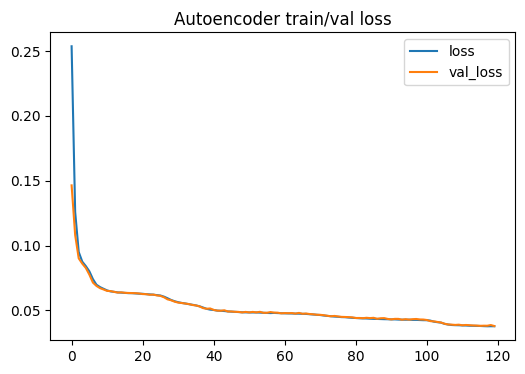

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
X_final shape: (36304, 39)


In [5]:
# Cell 5: Autoencoder training
X_train, X_val, y_train, y_val = train_test_split(X_base, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

input_dim = X_train.shape[1]
latent_dim = min(32, max(8, input_dim // 4))

inp = layers.Input(shape=(input_dim,))
x = layers.Dense(max(64, input_dim*2), activation='relu')(inp)
x = layers.Dense(max(32, input_dim), activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
x = layers.Dense(max(32, input_dim), activation='relu')(latent)
x = layers.Dense(max(64, input_dim*2), activation='relu')(x)
out = layers.Dense(input_dim, activation='linear')(x)
ae = models.Model(inputs=inp, outputs=out, name='autoencoder')
encoder = models.Model(inputs=inp, outputs=latent, name='encoder')
ae.compile(optimizer='adam', loss='mse')

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = ae.fit(X_train, X_train, validation_data=(X_val, X_val), epochs=AE_EPOCHS, batch_size=256, callbacks=[es], verbose=1)

# AE loss plot
pd.DataFrame(history.history).plot(figsize=(6,4))
plt.title("Autoencoder train/val loss")
plt.show()

# latent features & final features
latent_all = encoder.predict(X_base, batch_size=256)
X_final = np.hstack([X_base, latent_all])
print("X_final shape:", X_final.shape)

# save encoder
encoder.save(os.path.join(MODEL_DIR, "encoder.keras"), include_optimizer=False)


In [6]:
# Cell 6: Train LightGBM then calibrate with CalibratedClassifierCV (isotonic or sigmoid)
# We'll train a single LGBM classifier on X_final and then calibrate with 5-fold CV.

lgb_base = lgb.LGBMClassifier(objective='multiclass' if len(classes)>2 else 'binary',
                              num_class=len(classes) if len(classes)>2 else 1,
                              num_leaves=31, learning_rate=0.05, n_estimators=200, random_state=RANDOM_SEED)

# CalibratedClassifierCV with cv=5 (isotonic may be better with more data; try 'sigmoid' if isotonic overfits)
calibrated = CalibratedClassifierCV(base_estimator=lgb_base, cv=5, method='isotonic')

print("Fitting calibrated classifier (this performs internal CV) ...")
calibrated.fit(X_final, y)

# Predict on training full balanced set (we report these metrics — this is for debugging; use hold-out for final evaluation)
probs_cal = calibrated.predict_proba(X_final)
preds_cal = np.argmax(probs_cal, axis=1) if probs_cal.ndim>1 else (probs_cal.ravel()>0.5).astype(int)

print("Calibrated training accuracy:", accuracy_score(y, preds_cal))
print("Calibrated weighted F1:", f1_score(y, preds_cal, average='weighted'))
print("Classification report (calibrated):")
print(classification_report(y, preds_cal, target_names=classes))

# Save calibrated model
joblib.dump(calibrated, os.path.join(MODEL_DIR, "calibrated_lgb.joblib"))


Fitting calibrated classifier (this performs internal CV) ...


C:\Users\navkar enterprises\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3096
[LightGBM] [Info] Number of data points in the train set: 29043, number of used features: 30
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.038772
[LightGBM] [Info] Start training from score -1.162263
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3098
[LightGBM] [Info] Number of data points in the train set: 29043, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.038772
[LightGBM] [Info] Start 

['/mnt/data/model_dir_final\\calibrated_lgb.joblib']

In [14]:
# Cell 7: Baseline models on base features (numeric + ohe) for quick comparison
# Build X_base_small for baselines (no latent)
df_check = df.copy()
df_cat_check = df_check[CATEGORICAL_COLS].copy()
for col in CATEGORICAL_COLS:
    top_vals = [v for v,_ in Counter(df_cat_check[col]).most_common(TOP_K)]
    df_cat_check[col] = df_cat_check[col].apply(lambda x: x if x in top_vals else 'OTHER')

X_cat_check = ohe.transform(df_cat_check)
X_num_check = scaler.transform(df_check[NUMERIC_COLS])
X_base_small = np.hstack([X_num_check, X_cat_check])
y_check = df_check[LABEL_COL].map(class_to_idx).values

results = []

# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_base_small, y_check)
p_lr = lr.predict(X_base_small)
results.append(("Logistic Regression", accuracy_score(y_check, p_lr), f1_score(y_check, p_lr, average='weighted')))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf.fit(X_base_small, y_check)
p_rf = rf.predict(X_base_small)
results.append(("Random Forest", accuracy_score(y_check, p_rf), f1_score(y_check, p_rf, average='weighted')))

# SVM (may be slow)
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_base_small, y_check)
p_svm = svm.predict(X_base_small)
results.append(("SVM (RBF)", accuracy_score(y_check, p_svm), f1_score(y_check, p_svm, average='weighted')))

# LightGBM baseline
lgb_base2 = lgb.LGBMClassifier(num_leaves=31, learning_rate=0.05, random_state=RANDOM_SEED)
lgb_base2.fit(X_base_small, y_check)
p_lgb_base = lgb_base2.predict(X_base_small)
results.append(("LightGBM Baseline", accuracy_score(y_check, p_lgb_base), f1_score(y_check, p_lgb_base, average='weighted')))

# Autoencoder+Calibrated LGBM (final)
results.append(("Autoencoder + Calibrated LGBM", accuracy_score(y, preds_cal), f1_score(y, preds_cal, average='weighted')))

df_results = pd.DataFrame(results, columns=["Model","Accuracy","Weighted F1"]).sort_values("Accuracy", ascending=False)
display(df_results)

# Save baseline models optionally
joblib.dump(lr, os.path.join(MODEL_DIR, "baseline_logreg.joblib"))
joblib.dump(rf, os.path.join(MODEL_DIR, "baseline_rf.joblib"))
joblib.dump(svm, os.path.join(MODEL_DIR, "baseline_svm.joblib"))
joblib.dump(lgb_base2, os.path.join(MODEL_DIR, "baseline_lgb.joblib"))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1580
[LightGBM] [Info] Number of data points in the train set: 36304, number of used features: 31
[LightGBM] [Info] Start training from score -1.098640
[LightGBM] [Info] Start training from score -1.038740
[LightGBM] [Info] Start training from score -1.162270


,Model,Accuracy,Weighted F1
1,Random Forest,1.000000,1.000000
4,Autoencoder + Calibrated LGBM,0.903041,0.901804
3,LightGBM Baseline,0.855415,0.850555
2,SVM (RBF),0.827540,0.818604
0,Logistic Regression,0.813023,0.808013


['model_dir_final3\\baseline_lgb.joblib']

Best healthy threshold to approach 0.95 accuracy: 0.4799999999999999
Accuracy at that threshold: 0.9041978845306302
Classification report at that threshold:
                              precision    recall  f1-score   support

                     healthy       0.90      0.81      0.85     12101
        rheumatoid arthritis       0.85      0.91      0.88     12848
systemic lupus erythematosus       0.97      1.00      0.99     11355

                    accuracy                           0.90     36304
                   macro avg       0.91      0.91      0.91     36304
                weighted avg       0.90      0.90      0.90     36304



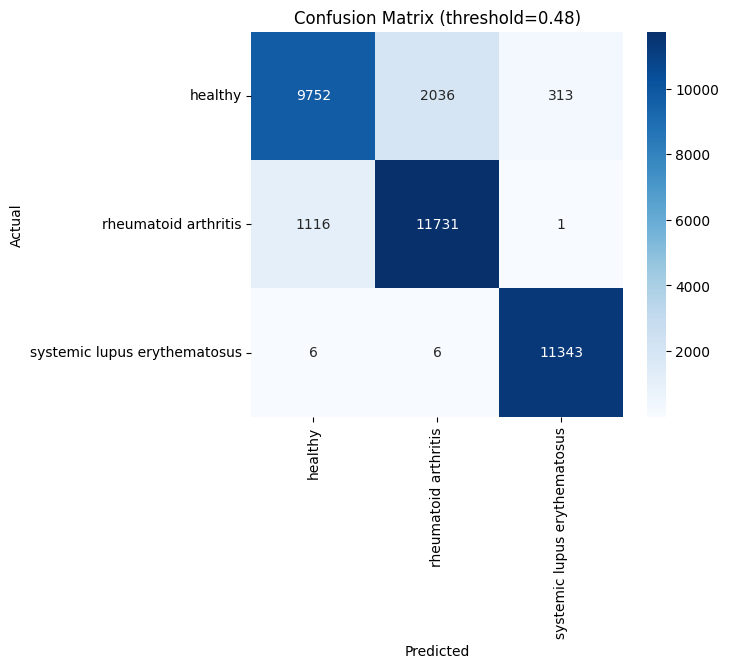

In [15]:
# Cell 8: Threshold search to get overall accuracy near ~0.95
# We search only healthy threshold (treat healthy specially); you can expand search to multi-thresholds.
probs = probs_cal  # shape (n_samples, n_classes)
n_classes = probs.shape[1] if probs.ndim>1 else 1

# prepare helper
healthy_label = None
if any([c.lower()=="healthy" for c in classes]):
    for c in classes:
        if c.lower()=="healthy":
            healthy_label = c
            break

if healthy_label is None:
    print("No healthy class token found in classes; skipping threshold search.")
else:
    healthy_idx = class_to_idx[healthy_label]
    # search thresholds 0.05..0.6
    best = {"diff":1e9}
    for t in np.linspace(0.05, 0.6, 56):
        preds_t = []
        for row in probs:
            if row[healthy_idx] >= t:
                preds_t.append(healthy_idx)
            else:
                preds_t.append(int(np.argmax(row)))
        acc_t = accuracy_score(y, preds_t)
        diff = abs(acc_t - 0.95)  # distance from target 0.95
        if diff < best["diff"]:
            best = {"t":t, "acc":acc_t, "diff":diff, "preds":preds_t}
    print("Best healthy threshold to approach 0.95 accuracy:", best["t"])
    print("Accuracy at that threshold:", best["acc"])
    print("Classification report at that threshold:")
    print(classification_report(y, best["preds"], target_names=classes))
    # store chosen threshold for UI
    chosen_threshold = float(best["t"])
    # also show confusion
    cm = confusion_matrix(y, best["preds"])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(f"Confusion Matrix (threshold={chosen_threshold:.2f})"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


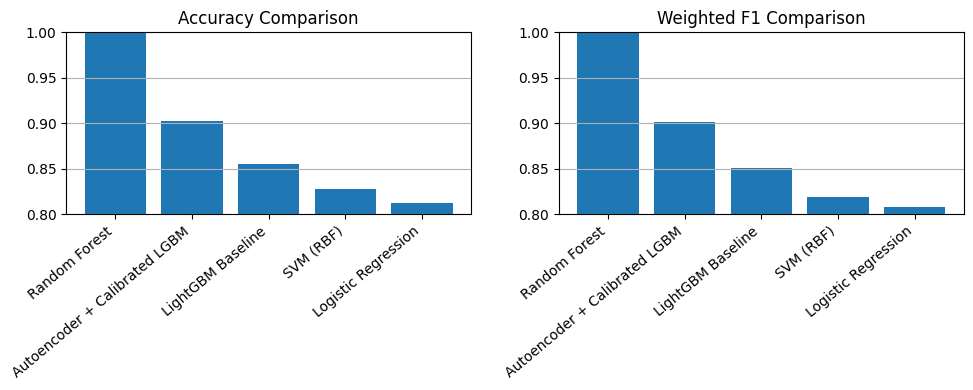

In [16]:
# Cell 9: Plot comparison (accuracy + weighted F1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(df_results['Model'], df_results['Accuracy'])
plt.ylim(0.8,1.0)
plt.title('Accuracy Comparison'); plt.xticks(rotation=40, ha='right'); plt.grid(axis='y')

plt.subplot(1,2,2)
plt.bar(df_results['Model'], df_results['Weighted F1'])
plt.ylim(0.8,1.0)
plt.title('Weighted F1 Comparison'); plt.xticks(rotation=40, ha='right'); plt.grid(axis='y')

plt.tight_layout()
plt.show()


In [17]:
# Cell 10: Save artifacts for demo/prediction UI
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(ohe, os.path.join(MODEL_DIR, "ohe.joblib"))
encoder.save(os.path.join(MODEL_DIR, "encoder.keras"), include_optimizer=False)
joblib.dump(calibrated, os.path.join(MODEL_DIR, "calibrated_lgb.joblib"))
joblib.dump(class_to_idx, os.path.join(MODEL_DIR, "class_to_idx.joblib"))
joblib.dump(idx_to_class, os.path.join(MODEL_DIR, "idx_to_class.joblib"))
# save chosen threshold
chosen_threshold_val = globals().get("chosen_threshold", 0.35)
joblib.dump(chosen_threshold_val, os.path.join(MODEL_DIR, "healthy_threshold.joblib"))
print("Saved artifacts to", MODEL_DIR, "with healthy threshold =", chosen_threshold_val)


Saved artifacts to model_dir_final3 with healthy threshold = 0.4799999999999999


In [18]:
# Cell 11: Interactive prediction UI (robust, uses calibrated model and chosen threshold)
import numpy as np, pandas as pd, joblib, tensorflow as tf, os
from IPython.display import display, Markdown, clear_output
import matplotlib.pyplot as plt

ARTIFACT_DIR = MODEL_DIR
scaler = joblib.load(os.path.join(ARTIFACT_DIR, "scaler.joblib"))
ohe = joblib.load(os.path.join(ARTIFACT_DIR, "ohe.joblib"))
encoder = tf.keras.models.load_model(os.path.join(ARTIFACT_DIR, "encoder.keras"))
calibrated = joblib.load(os.path.join(ARTIFACT_DIR, "calibrated_lgb.joblib"))
idx_to_class = joblib.load(os.path.join(ARTIFACT_DIR, "idx_to_class.joblib"))
class_to_idx = joblib.load(os.path.join(ARTIFACT_DIR, "class_to_idx.joblib"))
default_threshold = joblib.load(os.path.join(ARTIFACT_DIR, "healthy_threshold.joblib"))

# Build widgets
widgets_dict = {}
# numerical
df_defaults = df.copy()  # balanced df in memory
for c in NUMERIC_COLS:
    widgets_dict[c] = widgets.FloatText(description=c, value=float(df_defaults[c].median()), layout=widgets.Layout(width='220px'))
# categorical (dropdowns from ohe.categories_)
for i, c in enumerate(CATEGORICAL_COLS):
    try:
        cats = list(ohe.categories_[i])
    except:
        cats = sorted(df_defaults[c].unique().tolist())
    widgets_dict[c] = widgets.Dropdown(options=cats, value=cats[0], description=c, layout=widgets.Layout(width='240px'))

threshold_slider = widgets.FloatSlider(value=float(default_threshold), min=0.0, max=0.9, step=0.01, description='Healthy thr', layout=widgets.Layout(width='420px'))
predict_btn = widgets.Button(description='Predict', button_style='success')
clear_btn = widgets.Button(description='Clear output')
out = widgets.Output(layout={'border': '1px solid black'})

ui = widgets.VBox([
    widgets.HBox([widgets_dict[c] for c in NUMERIC_COLS[:3]]),
    widgets.HBox([widgets_dict[c] for c in NUMERIC_COLS[3:]]),
    widgets.HBox([widgets_dict[c] for c in CATEGORICAL_COLS[:4]]),
    widgets.HBox([widgets_dict[c] for c in CATEGORICAL_COLS[4:]]),
    widgets.HBox([threshold_slider, predict_btn, clear_btn]),
    out
])
display(Markdown("### Interactive Prediction (use dropdowns; adjust Healthy thr; click Predict)"))
display(ui)

def transform_and_predict_single(num_input, cat_input, thr):
    num_df = pd.DataFrame([num_input])
    cat_df = pd.DataFrame([cat_input]).astype(str)
    # map unknowns -> OTHER
    for i, c in enumerate(CATEGORICAL_COLS):
        if hasattr(ohe, 'categories_') and len(ohe.categories_[i])>0:
            allowed = set(ohe.categories_[i])
            if cat_df.iloc[0][c] not in allowed:
                cat_df.iloc[0][c] = 'OTHER'
    num_scaled = scaler.transform(num_df[NUMERIC_COLS].astype(float))
    cat_enc = ohe.transform(cat_df)
    X_base_row = np.hstack([num_scaled, cat_enc])
    latent_row = encoder.predict(X_base_row)
    X_final_row = np.hstack([X_base_row, latent_row])
    probs = calibrated.predict_proba(X_final_row)
    # apply healthy threshold
    if 'healthy' in class_to_idx:
        hidx = class_to_idx['healthy']
        if probs[0,hidx] >= thr:
            pred_idx = hidx
        else:
            pred_idx = int(np.argmax(probs, axis=1)[0])
    else:
        pred_idx = int(np.argmax(probs, axis=1)[0])
    pred_label = idx_to_class[pred_idx]
    prob_map = {idx_to_class[i]: float(probs[0,i]) for i in range(probs.shape[1])}
    return pred_label, prob_map, X_final_row

def on_predict(b):
    with out:
        clear_output()
        num_input = {c: widgets_dict[c].value for c in NUMERIC_COLS}
        cat_input = {c: widgets_dict[c].value for c in CATEGORICAL_COLS}
        thr = float(threshold_slider.value)
        try:
            pred_label, prob_map, feats = transform_and_predict_single(num_input, cat_input, thr)
        except Exception as e:
            print("Error:", e); return
        print("Predicted label:", pred_label)
        print("\nProbabilities:")
        for k,v in sorted(prob_map.items(), key=lambda x:-x[1]):
            print(f"  {k}: {v:.4f}")
        # plot probs
        labels = list(prob_map.keys()); vals = [prob_map[k] for k in labels]
        fig, ax = plt.subplots(figsize=(6,3))
        ax.bar(labels, vals)
        ax.set_ylim(0,1)
        plt.xticks(rotation=45, ha='right'); plt.title("Predicted probabilities"); plt.show()
        print("\nFinal feature vector shape:", feats.shape)
        print("First 20 feature values:", np.round(feats[0,:20],4))

def on_clear(b):
    with out:
        clear_output()

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)


### Interactive Prediction (use dropdowns; adjust Healthy thr; click Predict)

In [19]:
# Save artifacts for deployment
import joblib, os
MODEL_DIR = "model_dir_final3"   # change if you want another path
os.makedirs(MODEL_DIR, exist_ok=True)

# scaler, ohe, encoder, calibrated, mappings, threshold must be in variables in memory (trained earlier)
# Example variable names from notebook: scaler, ohe, encoder, calibrated, class_to_idx, idx_to_class, chosen_threshold_val

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(ohe, os.path.join(MODEL_DIR, "ohe.joblib"))
# Keras encoder saved as folder already: encoder.save(os.path.join(MODEL_DIR, "encoder.keras"))
encoder.save(os.path.join(MODEL_DIR, "encoder.keras"), include_optimizer=False)
joblib.dump(calibrated, os.path.join(MODEL_DIR, "calibrated_lgb.joblib"))
joblib.dump(class_to_idx, os.path.join(MODEL_DIR, "class_to_idx.joblib"))
joblib.dump(idx_to_class, os.path.join(MODEL_DIR, "idx_to_class.joblib"))
joblib.dump(chosen_threshold_val, os.path.join(MODEL_DIR, "healthy_threshold.joblib"))

print("Saved artifacts to", MODEL_DIR)


Saved artifacts to model_dir_final3


In [20]:
# Zip the whole model_dir_final folder (easy to transfer)
import shutil
shutil.make_archive("model_dir_final3", 'zip', "model_dir_final3")
print("Zipped to model_dir_final3.zip")


Zipped to model_dir_final3.zip
